# Notebook 3: Validación de la Imputación de Huecos 

<div style="text-align: justify;">

En este notebook se ejecutan una batería de pruebas a través de la API, donde se validan los modelos en catálogo encargados de la imputación de huecos, mediante daños inyectados (huecos) en el modo sandbox. La validación se lleva a cabo en dos fases, en la primera de ellas los modelos no son optimizados. En la segunda, se habilita la Optimización de Hiperparámetros (HPO).

</div>

## Índice de Contenidos

1. [Preparación del Entorno](#preparacion)
2. [Carga y Estructuración de Datos](#carga-datos)
3. [Torneo Base de Imputación de Huecos](#torneo-base)
4. [Torneo de Imputación de Huecos: HPO & Feature Engineering](#torneo-hpo)
5. [Resultados y Visualización](#resultados-visualizacion)
6. [Conclusiones](#conclusiones)

## 1. Preparación del Entorno <a id="preparacion"></a>

<div style="text-align: justify;">

En esta fase inicial, procedemos a importar las librerías necesarias para las pruebas (manipulación de datos, peticiones HTTP y visualización). Se definen las variables de entorno y se ejecuta una comprobación de salud (*Health Check*) para verificar que la API se encuentra operativa y lista para recibir peticiones.

</div>

In [27]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Configuraciones de red
SERVER_BASE_URL = "http://127.0.0.1:8000"
API_BASE = f"{SERVER_BASE_URL}/api/v1"
DIAGNOSE_URL = f"{API_BASE}/jobs/sandbox/diagnose"
DIAGNOSE_DATASET_URL = f"{API_BASE}/jobs/sandbox/diagnose-dataset"

# Variables para el polling asíncrono
POLL_SECONDS = 2
TIMEOUT_SECONDS = 7200

base_job_uuid = None
hpo_job_uuid = None

# Health Check
health_response = requests.get(f"{SERVER_BASE_URL}/health")
print(health_response.json())

{'status': 'ok', 'version': '1.0.0'}


## 2. Carga y Estructuración de Datos <a id="carga-datos"></a>

<div style="text-align: justify;">

La validación se ejecutará sobre los siguientes dos conjuntos de datos, ya presentados en `00_download_tsdb_datasets.ipynb`:
1. Alumbrado Público (Regular)
2. Beijing Air Quality (Multivariante)

A continuación, se cargan los archivos y se acondicionan para cumplir el contrato de integración de la API.

</div>

In [68]:
def register_catalog_in_api(name, df, frequency="1h"):
    print(f"Sincronizando '{name}' con el catálogo de la API...")
    
    # 1. Buscar o crear el Dataset
    datasets_resp = requests.get(f"{API_BASE}/datasets", timeout=10)
    datasets_resp.raise_for_status()
    
    # Buscamos si ya existe uno con el mismo nombre
    dataset_id = next((ds["id"] for ds in datasets_resp.json() if ds["name"] == name), None)
    
    if not dataset_id:
        ds_resp = requests.post(f"{API_BASE}/datasets", json={
            "name": name, 
            "description": "Auto-generado desde Jupyter Notebook"
        }, timeout=10)
        ds_resp.raise_for_status()
        dataset_id = ds_resp.json()["id"]
        
    # 2. Buscar o crear las Señales
    signals_resp = requests.get(f"{API_BASE}/datasets/{dataset_id}/signals", timeout=10)
    signals_resp.raise_for_status()
    existing_signals = {str(sig["name"]): sig["id"] for sig in signals_resp.json()}
    
    signal_mappings = {}
    for col in df.columns:
        col_str = str(col)
        if col_str in existing_signals:
            signal_mappings[col_str] = existing_signals[col_str]
        else:
            sig_resp = requests.post(f"{API_BASE}/datasets/{dataset_id}/signals", json={
                "name": col_str,
                "frequency": frequency
            }, timeout=10)
            sig_resp.raise_for_status()
            signal_mappings[col_str] = sig_resp.json()["id"]
            
    print(f"   Dataset ID: {dataset_id} | Señales listas: {len(signal_mappings)}")
    return dataset_id, signal_mappings

def prepare_dataset_payload(df, dataset_id, signal_mappings):
    timestamps = df.index.strftime('%Y-%m-%dT%H:%M:%SZ').tolist()
    signals = []
    for col in df.columns:
        values = df[col].tolist()
        input_data = [{"timestamp": t, "value": v} for t, v in zip(timestamps, values)]
        signals.append({
            "signal_id": signal_mappings[str(col)],
            "source_signal_ref": str(col),
            "input_data": input_data,
            "preferences": {}
        })
    return {
        "dataset_id": dataset_id,
        "signals": signals
    }

# Establecemos un límite de 1 año de datos para hacer la prueba más ligera
MAX_ROWS = 8760

# 1. Alumbrado Público Regular (1 variable)
df_alumbrado = pd.read_csv('datasets/alumbrado_1.csv', sep=';', decimal=',')
df_alumbrado.set_index('Fecha', inplace=True)
df_alumbrado.index = pd.to_datetime(df_alumbrado.index, dayfirst=True)
df_alumbrado.columns = ['consumo']
df_alumbrado = df_alumbrado.iloc[:MAX_ROWS]

alumbrado_ds_id, alumbrado_sig_map = register_catalog_in_api("Alumbrado Publico", df_alumbrado, "1h")
payload_alumbrado = prepare_dataset_payload(df_alumbrado, alumbrado_ds_id, alumbrado_sig_map)

# 2. Beijing Air Quality (12 variables)
df_beijing = pd.read_csv('datasets/beijing_multisite_air_quality/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df_beijing['timestamp'] = pd.to_datetime(df_beijing[['year', 'month', 'day', 'hour']])
df_beijing = df_beijing.set_index('timestamp')
df_beijing = df_beijing.iloc[:MAX_ROWS]
df_beijing = df_beijing.drop(columns=['No', 'year', 'month', 'day', 'hour', "wd", "WSPM", 'station', 'RAIN'])

beijing_ds_id, beijing_sig_map = register_catalog_in_api("Beijing Air Quality", df_beijing, "1h")
payload_beijing = prepare_dataset_payload(df_beijing, beijing_ds_id, beijing_sig_map)

Sincronizando 'Alumbrado Publico' con el catálogo de la API...
   Dataset ID: 1 | Señales listas: 1
Sincronizando 'Beijing Air Quality' con el catálogo de la API...
   Dataset ID: 4 | Señales listas: 9


## 3. Torneo Base de Imputación de Huecos <a id="torneo-base"></a>

<div style="text-align: justify;">

En esta sección, se evalúa el rendimiento del catálogo de modelos en su estado base, es decir, sin la intervención del motor de Optimización de Hiperparámetros (HPO) ni del módulo de Ingeniería de Características (*Feature Engineering*). 

Para cada dataset, se configurará una petición hacia el Sandbox de la API con los siguientes parámetros:
* **Tarea objetivo `target_task = "IMPUTATION"`**: Instruye al motor para que evalúe y promueva modelos basándose exclusivamente en su capacidad de reconstrucción.
* **Inyecciones Sintéticas:** Se inyectarán huecos (*gaps*) de datos.
* **Optimización de Hiperparámetros `enable_hpo = False`**: Desactiva la optimización bayesiana.

</div>

In [ ]:
# 0. Configuración de las inyecciones
INJ_GAP_1_START = 100
INJ_GAP_1_SIZE = 12  # Simulamos una pérdida de conexión/datos de 12 horas

INJ_GAP_2_START = 300
INJ_GAP_2_SIZE = 12  # Simulamos una pérdida de conexión/datos de 12 horas

INJ_GAP_3_START = 500
INJ_GAP_3_SIZE = 24  # Simulamos una pérdida de conexión/datos de 24 horas

injections_config = [
    {"type": "gap", "size_steps": INJ_GAP_1_SIZE, "start_idx": INJ_GAP_1_START},
    {"type": "gap", "size_steps": INJ_GAP_2_SIZE, "start_idx": INJ_GAP_2_START},
    {"type": "gap", "size_steps": INJ_GAP_3_SIZE, "start_idx": INJ_GAP_3_START}
]

sandbox_config = {
    "target_task": "IMPUTATION",
    "enable_hpo": False,
    "promotion_metric": "imputation_mae",
    "injections": injections_config,
}

# 1. Configuración Univariante
sandbox_uni_config = dict(sandbox_config)
sandbox_uni_config["candidate_model_specs"] = [
    {
        "name": "ZSCORE_LINEAR",
        "detector_model": "ZSCORE",
        "imputation_model": "LINEAR"
    },
    {
        "name": "UNI_LIGHTGBM_TABULAR",
        "detector_model": "LIGHTGBM_RESIDUAL",
        "imputation_model": "LIGHTGBM_TABULAR"
    }
]

# 2. Configuración Multivariante (2 modelos para no hacer la prueba demasiado pesada)
sandbox_multi_config = dict(sandbox_config)
sandbox_multi_config["candidate_model_specs"] = [
    {
        "name": "MULTI_AUTOENCODER_SOFTIMPUTE",
        "detector_model": "AUTOENCODER",
        "imputation_model": "SOFTIMPUTE",
    },
    {
        "name": "MULTI_SAITS",
        "detector_model": "SAITS_RECONSTRUCTION",
        "imputation_model": "SAITS_IMPUTATION",
    }
]

job_uuids = {}

In [4]:
# 1. Alumbrado (Univariante)
alumbrado_single_payload = {
    "signal_id": payload_alumbrado["signals"][0]["signal_id"], 
    "input_data": payload_alumbrado["signals"][0]["input_data"],
    "sandbox_config": sandbox_uni_config,
    "preferences": {
        "enable_feature_engineering": False,
    }
}

print(" Enviando petición para Alumbrado...")
r_alumbrado = requests.post(DIAGNOSE_URL, json=alumbrado_single_payload, timeout=60)
r_alumbrado.raise_for_status()
job_uuids['Alumbrado'] = r_alumbrado.json().get("id")
print(f"   Alumbrado aceptado. Ticket UUID: {job_uuids['Alumbrado']}")

 Enviando petición para Alumbrado...
   Alumbrado aceptado. Ticket UUID: d79e5661-f592-4c4b-8d05-ecc1f50f74c6


In [70]:
import math

# Function to recursively replace NaN with None in a list of dictionaries
def sanitize_payload_data(input_data):
    sanitized = []
    for row in input_data:
        clean_row = {}
        for key, val in row.items():
            if isinstance(val, float) and math.isnan(val):
                clean_row[key] = None
            else:
                clean_row[key] = val
        sanitized.append(clean_row)
    return sanitized

# 2. Beijing Air Quality (Multivariante)
for name, payload in [("Beijing_AQ", payload_beijing)]:
    payload["sandbox_config"] = sandbox_multi_config
    payload["shared_preferences"] = {
        "enable_feature_engineering": False,
    }
    
    # Sanitize NaN values for JSON compliance
    for signal in payload["signals"]:
        signal["input_data"] = sanitize_payload_data(signal["input_data"])
        signal["preferences"] = {"enable_feature_engineering": False}
        
    print(f"\n Enviando petición para {name}...")
    resp = requests.post(DIAGNOSE_DATASET_URL, json=payload, timeout=60)
    resp.raise_for_status()
    job_uuids[name] = resp.json().get("id")
    print(f"   {name} aceptado. Ticket UUID: {job_uuids[name]}")


 Enviando petición para Beijing_AQ...
   Beijing_AQ aceptado. Ticket UUID: f107dcd6-ead5-4376-b4fd-533f5cc7a25c


### Monitorización Asíncrona (*Polling*) <a id="polling"></a>

<div style="text-align: justify;">

Una vez obtenidos los identificadores únicos (UUIDs) de los dos trabajos, se inicia un bucle de monitorización no bloqueante hacia el *endpoint* `GET /api/v1/jobs/{UUID}`. Este bucle consultará el estado de las tareas hasta que todas alcancen el estado `completed` o `failed`.

</div>

In [6]:
import sys

def poll_multiple_jobs(uuids_dict, poll_seconds=POLL_SECONDS, timeout_seconds=TIMEOUT_SECONDS):
    """
    Monitoriza múltiples jobs concurrentemente hasta que todos terminen (completed o failed).
    """
    pending_jobs = list(uuids_dict.keys())
    final_results = {}
    start_time = time.time()
    
    print("Iniciando polling...")
    
    while pending_jobs:
        if time.time() - start_time > timeout_seconds:
            raise TimeoutError("Se ha superado el tiempo de espera (timeout) en el polling.")
            
        for name in list(pending_jobs):
            uuid = uuids_dict[name]
            status_url = f"{API_BASE}/jobs/{uuid}"
            
            try:
                r = requests.get(status_url, timeout=30)
                r.raise_for_status()
                body = r.json()
                status = str(body.get("status", "unknown")).lower()
                
                # Imprimimos el estado en la misma línea para no saturar el output
                sys.stdout.write(f"\r[{int(time.time() - start_time)}s] Estados -> ")
                for n, uid in uuids_dict.items():
                    sys.stdout.write(f"{n}: {status if n == name else '...'} | ")
                sys.stdout.flush()
                
                if status in {"completed", "failed"}:
                    print(f"\n   Job '{name}' ha terminado con estado: {status.upper()}")
                    final_results[name] = body
                    pending_jobs.remove(name)
                    
            except requests.exceptions.RequestException as e:
                print(f"\n   Error conectando con la API para el job {name}: {e}")
                
        time.sleep(poll_seconds)
        
    return final_results

# Lanzamos el polling para los torneos base
print("\n--- Monitorizando Torneos Base ---")
base_job_statuses = poll_multiple_jobs(job_uuids)


--- Monitorizando Torneos Base ---
Iniciando polling...
[0s] Estados -> Alumbrado: completed | Beijing_AQ: ... | 


   Job 'Alumbrado' ha terminado con estado: COMPLETED
[128s] Estados -> Alumbrado: ... | Beijing_AQ: completed | 
   Job 'Beijing_AQ' ha terminado con estado: COMPLETED


## 4. Torneo de Imputación de Huecos: HPO & Feature Engineering <a id="torneo-hpo"></a>

<div style="text-align: justify;">

Una vez obtenida la métrica de rendimiento con configuración cero, procedemos a activar la inteligencia del motor. Para ello, enviaremos los mismos datos bajo el mismo estrés sintético, pero habilitando:

1. Optimización de Hiperparámetros (`enable_hpo=True`) 
2. Generación automática de características para escenario univariante con `enable_feature_engineering`

</div>

In [ ]:
# 1. Configuración HPO Univariante
sandbox_uni_hpo_config = {
    "target_task": "IMPUTATION",
    "enable_hpo": True,
    "promotion_metric": "imputation_mae",
    "injections": injections_config,
    "hpo_config": {
        "n_trials": 20,
        "timeout_seconds": 7200,
        "metric": "imputation_mae" 
    },
    "scoring_weights": {"detection_weight": 0.0, "imputation_weight": 1.0}
}
sandbox_uni_hpo_config["candidate_model_specs"] = [
    {
        "name": "ZSCORE_LINEAR",
        "detector_model": "ZSCORE",
        "imputation_model": "LINEAR"
    },
    {
        "name": "UNI_LIGHTGBM_TABULAR",
        "detector_model": "LIGHTGBM_RESIDUAL",
        "imputation_model": "LIGHTGBM_TABULAR"
    }
]

# 2. Configuración HPO Multivariante
sandbox_multi_hpo_config = dict(sandbox_uni_hpo_config)
sandbox_multi_hpo_config["candidate_model_specs"] = [
    {
        "name": "MULTI_AUTOENCODER_SOFTIMPUTE",
        "detector_model": "AUTOENCODER",
        "imputation_model": "SOFTIMPUTE",
    },
    {
        "name": "MULTI_SAITS",
        "detector_model": "SAITS_RECONSTRUCTION",
        "imputation_model": "SAITS_IMPUTATION",
    }
]

hpo_job_uuids = {}

In [ ]:
# 1. Alumbrado Público (Endpoint Univariante HPO)
alumbrado_hpo_payload = {
    "signal_id": payload_alumbrado["signals"][0]["signal_id"], 
    "input_data": payload_alumbrado["signals"][0]["input_data"],
    "sandbox_config": sandbox_uni_hpo_config,
    "preferences": {"enable_feature_engineering": True}
}

print(" Enviando petición HPO univariante para Alumbrado...")
try:
    r_alumbrado = requests.post(DIAGNOSE_URL, json=alumbrado_hpo_payload, timeout=60)
    r_alumbrado.raise_for_status()
    hpo_job_uuids['Alumbrado'] = r_alumbrado.json().get("id")
    print(f"   Alumbrado HPO aceptado. Ticket UUID: {hpo_job_uuids['Alumbrado']}")
except requests.exceptions.RequestException as e:
    print(f"   Fallo. Detalles: {e.response.json() if hasattr(e, 'response') and e.response is not None else e}")

 Enviando petición HPO univariante para Alumbrado...
   Alumbrado HPO aceptado. Ticket UUID: 353f1778-e300-48b0-b6da-7b7df2061b9c


In [75]:
# Function to recursively replace NaN with None in a list of dictionaries
def sanitize_payload_data(input_data):
    sanitized = []
    for row in input_data:
        clean_row = {}
        for key, val in row.items():
            if isinstance(val, float) and math.isnan(val):
                clean_row[key] = None
            else:
                clean_row[key] = val
        sanitized.append(clean_row)
    return sanitized

# 2. Beijing Air Quality (Multivariante)
for name, payload in [("Beijing_AQ", payload_beijing)]:
    payload["sandbox_config"] = sandbox_multi_hpo_config
    payload["shared_preferences"] = {
        "enable_feature_engineering": False
    }
    # Sanitize NaN values for JSON compliance
    for signal in payload["signals"]:
        signal["input_data"] = sanitize_payload_data(signal["input_data"])
        signal["preferences"] = {"enable_feature_engineering": False}
        
    print(f"\n Enviando petición para {name}...")
    resp = requests.post(DIAGNOSE_DATASET_URL, json=payload, timeout=60)
    resp.raise_for_status()
    hpo_job_uuids[name] = resp.json().get("id")
    print(f"   {name} aceptado. Ticket UUID: {hpo_job_uuids[name]}")


 Enviando petición para Beijing_AQ...
   Beijing_AQ aceptado. Ticket UUID: 5be19b3f-a9ea-4c08-a05f-372ef4d9284e


### Monitorización Asíncrona (*Polling*) <a id="polling"></a>

<div style="text-align: justify;">

Una vez obtenidos los nuevos identificadores únicos (UUIDs) de los tres trabajos, se consultan los jobs de la misma manera que antes.

</div>

In [13]:
print("--- Monitorizando Torneos (HPO & Feature Engineering) ---")
# Usamos la función de polling definida anteriormente
hpo_statuses = poll_multiple_jobs(hpo_job_uuids, poll_seconds=5)

--- Monitorizando Torneos (HPO & Feature Engineering) ---
Iniciando polling...
[61s] Estados -> Alumbrado: completed | Beijing_AQ: ... | mbrado: ... | Beijing_AQ: running | 
   Job 'Alumbrado' ha terminado con estado: COMPLETED
[283s] Estados -> Alumbrado: ... | Beijing_AQ: completed | 
   Job 'Beijing_AQ' ha terminado con estado: COMPLETED


## 5. Resultados y Visualizacion <a id="resultados-visualizacion"></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

def extraer_ranking_completo(job_id, dataset_name, fase="Zero-Shot"):
    """Extrae las métricas de TODOS los modelos para la tarea de Imputación (MAE y RMSE)."""
    results_data = []
    try:
        resp = requests.get(f"{API_BASE}/jobs/{job_id}/result/summary", timeout=10)
        if resp.status_code == 200:
            sandbox = resp.json().get("summary", {}).get("sandbox", {})
        else:
            resp = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=15)
            resp.raise_for_status()
            sandbox = resp.json().get("result", {}).get("summary", {}).get("sandbox", {})
        
        ranking = sandbox.get("detailed_ranking", [])
        runs = sandbox.get("model_runs", [])
        
        for rank_item in ranking:
            model_name = rank_item.get("model_name", "Desconocido")
            r_pos = rank_item.get("rank", 0)
            sec_metrics = rank_item.get("secondary_metrics", {})
            
            run_data = next((r for r in runs if r.get("name") == model_name), {})
            imp_metrics = run_data.get("metrics", {}).get("imputation", {})
            
            # Extraemos MAE y RMSE específicos de la zona del GAP
            mae_gap = imp_metrics.get("mae_gap") or sec_metrics.get("imputation_mae") or rank_item.get("primary_metric_score", 0.0) or 0.0
            rmse_gap = imp_metrics.get("rmse_gap") or 0.0
            
            results_data.append({
                "Rank": r_pos,
                "Modelo": model_name,
                "MAE Gap": round(mae_gap, 4) if mae_gap is not None else None,
                "RMSE Gap": round(rmse_gap, 4) if rmse_gap is not None else None,
                "Fase": fase
            })
    except Exception as e:
        print(f"  Error procesando la tabla de {dataset_name}: {e}")

    df = pd.DataFrame(results_data)
    if not df.empty:
        df = df.sort_values(by="Rank").reset_index(drop=True)
    return df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

def graficar_diagnostico_zoom(job_id, dataset_name, dias_zoom=3):
    """
    Grafica las señales de forma dinámica y calcula en tiempo real las métricas 
    locales de MAE y RMSE para cada variable de forma aislada y en su propia escala.
    """
    try:
        # 1. Recuperar el manifiesto completo de inyecciones desde el resumen del Job
        url_summary = f"{API_BASE}/jobs/{job_id}/result/summary"
        resp_sum = requests.get(url_summary)
        if resp_sum.status_code == 200:
            sandbox = resp_sum.json().get("summary", {}).get("sandbox", {})
        else:
            resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}")
            sandbox = resp_sum.json().get("result", {}).get("summary", {}).get("sandbox", {})
            
        manifest = sandbox.get("competition_metadata", {}).get("test_scenario", {}).get("injection_manifest", [])
        
        # Filtrar e indexar las franjas de tipo GAP
        gaps_info = []
        for inj in manifest:
            if inj.get("type") == "gap":
                start = inj.get("start_idx")
                size = inj.get("size_steps", 1)
                cols = inj.get("columns", [])
                gaps_info.append({"start": start, "end": start + size - 1, "cols": cols})
                
        if not gaps_info:
            print(f" No se han encontrado inyecciones de tipo GAP en el Job {job_id}.")
            return

        # 2. Consultar los datos de las series temporales resultantes
        url_ts = f"{API_BASE}/jobs/{job_id}/result?offset=0&limit=20000"
        resp_ts = requests.get(url_ts, timeout=30)
        resp_ts.raise_for_status()
        
        ts_list = resp_ts.json().get("timeseries_data", [])
        if not ts_list:
            print(f" No hay datos temporales disponibles para {dataset_name}.")
            return
            
        df_ts = pd.DataFrame(ts_list)
        df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
        signals = sorted(df_ts['signal_id'].unique())
        
        # Configurar la cuadrícula (1 fila independiente por cada sensor)
        fig, axes = plt.subplots(len(signals), 1, figsize=(14, 4.8 * len(signals)))
        if len(signals) == 1: axes = [axes]
            
        for i, sig_id in enumerate(signals):
            ax = axes[i]
            sig_name = f"sensor_{sig_id}"
            
            # Filtrar histórico exclusivo de este sensor
            df_sig = df_ts[df_ts['signal_id'] == sig_id].copy()
            df_sig.sort_values('timestamp', inplace=True)
            df_sig.reset_index(drop=True, inplace=True)
            
            min_gap_idx = min(g["start"] for g in gaps_info)
            max_gap_idx = max(g["end"] for g in gaps_info)
            
            if max_gap_idx >= len(df_sig):
                ax.set_title(f"{sig_name} - Índices fuera de rango histórico")
                continue
                
            t_view_start = df_sig.iloc[min_gap_idx]['timestamp']
            t_view_end = df_sig.iloc[max_gap_idx]['timestamp']
            window = pd.Timedelta(days=dias_zoom)
            right_window = pd.Timedelta(days=dias_zoom+2)
            
            df_zone = df_sig[(df_sig['timestamp'] >= t_view_start - window) & (df_sig['timestamp'] <= t_view_end + right_window)]
            
            # Identificar si esta señal concreta fue afectada por el Sandbox
            is_signal_damaged = False
            for gap in gaps_info:
                cols = gap["cols"]
                if not cols or "all_signals" in cols or sig_name in cols:
                    is_signal_damaged = True
                    break
            
            # Sombrear ventanas de GAP e inicializar máscara booleana para cálculo de error local
            added_bg_label = False
            in_gap_mask = pd.Series(False, index=df_zone.index)
            
            for gap in gaps_info:
                cols = gap["cols"]
                if not cols or "all_signals" in cols or sig_name in cols:
                    t_s = df_sig.iloc[gap["start"]]['timestamp']
                    t_e = df_sig.iloc[gap["end"]]['timestamp']
                    
                    # Almacenar índices cronológicos de este GAP específico
                    in_gap_mask |= (df_zone['timestamp'] >= t_s) & (df_zone['timestamp'] <= t_e)
                    
                    bg_label = 'Franja del Gap Inyectado' if not added_bg_label else None
                    ax.axvspan(t_s, t_e, color='orange', alpha=0.18, label=bg_label)
                    added_bg_label = True
            
            # 3. CÁLCULO DE MÉTRICAS LOCALES DE FORMA AISLADA (Evita la distorsión de escalas)
            metricas_title_str = "Sin alteraciones"
            if is_signal_damaged:
                # Extraer exclusivamente los puntos imputados dentro de la franja del GAP
                df_gap_data = df_zone[in_gap_mask].dropna(subset=['original_value', 'final_value'])
                
                if not df_gap_data.empty:
                    # Medimos el error real comparando las dos columnas devueltas por la API
                    local_mae = (df_gap_data['original_value'] - df_gap_data['final_value']).abs().mean()
                    local_rmse = np.sqrt(((df_gap_data['original_value'] - df_gap_data['final_value']) ** 2).mean())
                    metricas_title_str = f"Local MAE: {local_mae:.4f} | Local RMSE: {local_rmse:.4f}"
                else:
                    metricas_title_str = "Error: Datos del Gap no detectados"
            
            # 4. Pintado gráfico condicional
            if is_signal_damaged:
                ax.plot(df_zone['timestamp'], df_zone['original_value'], color='#7f7f7f', linestyle='--', alpha=0.7, label="Valor Real (Ground Truth)")
                ax.plot(df_zone['timestamp'], df_zone['final_value'], color='#1f77b4', linewidth=1.8, label="Señal Resultante")
                
                if 'is_imputed' in df_zone.columns:
                    imputed_series = df_zone['final_value'].copy()
                    imputed_series[~(df_zone['is_imputed'] & in_gap_mask)] = None
                    ax.plot(df_zone['timestamp'], imputed_series, color='#d62728', linewidth=2.0, label="Zona Imputada (Modelo)")
                    
                    df_imputed_points = df_zone[df_zone['is_imputed'] & in_gap_mask]
                    if not df_imputed_points.empty:
                        ax.scatter(df_imputed_points['timestamp'], df_imputed_points['final_value'], 
                                   color='#d62728', marker='o', s=15, zorder=5, label="Puntos Imputados")
            else:
                ax.plot(df_zone['timestamp'], df_zone['final_value'], color='#1f77b4', linewidth=1.8, label="Señal Saneada")
            
            # Inyectamos el desglose de métricas locales sin mezclar escalas en el título del gráfico
            ax.set_title(f"{dataset_name} | {sig_name} | Reconstrucción GAP ({metricas_title_str})", fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.25)
            
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='upper right')
            
        plt.tight_layout(pad=3.0)
        plt.show()
    except Exception as e:
        print(f" Error al generar las gráficas dinámicas de {dataset_name}: {e}")

### 5.1. Torneo Base (sin HPO)

<div style="text-align: justify;">

Se exponen a continuación los rankings de los modelos evaluados en el torneo base, así como las gráficas construidas para su visualización, para cada uno de los dos datasets de evaluación.

</div>

#### 5.1.1 Alumbrado Público (Univariante)

,Rank,Modelo,MAE Gap,RMSE Gap,Fase
0,1,ZSCORE_LINEAR,0.744,1.119,Zero-Shot
1,2,UNI_LIGHTGBM_TABULAR,0.744,1.119,Zero-Shot


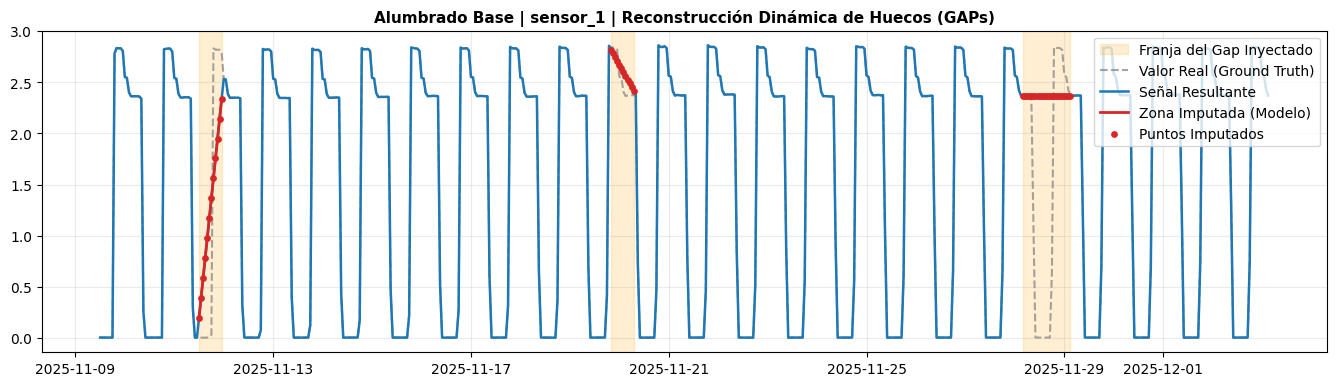

In [81]:
display(extraer_ranking_completo(job_uuids["Alumbrado"], "Alumbrado", "Zero-Shot"))
graficar_diagnostico_zoom(job_uuids["Alumbrado"], "Alumbrado Base", dias_zoom=2)

#### 5.1.2. Beijing Air Quality (Multivariante)

In [71]:
import numpy as np
import pandas as pd
import requests

def extraer_error_desglosado_por_gap(job_id):
    """
    Trocea el histórico y calcula el MAE y RMSE local para cada uno de los GAPs
    inyectados y cada sensor afectado, aislando por completo las escalas de las variables.
    """
    try:
        # 1. Recuperar las coordenadas de cada GAP desde el manifiesto del Job
        url_summary = f"{API_BASE}/jobs/{job_id}/result/summary"
        resp_sum = requests.get(url_summary)
        if resp_sum.status_code == 200:
            sandbox = resp_sum.json().get("summary", {}).get("sandbox", {})
        else:
            resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}")
            sandbox = resp_sum.json().get("result", {}).get("summary", {}).get("sandbox", {})
            
        manifest = sandbox.get("competition_metadata", {}).get("test_scenario", {}).get("injection_manifest", [])
        
        # Filtrar exclusivamente las perturbaciones de tipo hueco (gap)
        gaps_manifest = [inj for inj in manifest if inj.get("type") == "gap"]
        if not gaps_manifest:
            print(" No se han encontrado inyecciones de tipo GAP en este Job.")
            return None

        # 2. Descargar el histórico de series temporales completo desde la API
        url_ts = f"{API_BASE}/jobs/{job_id}/result?offset=0&limit=20000"
        resp_ts = requests.get(url_ts, timeout=30)
        resp_ts.raise_for_status()
        
        ts_list = resp_ts.json().get("timeseries_data", [])
        if not ts_list:
            print(" La API no ha devuelto datos temporales para este Job.")
            return None
            
        df_ts = pd.DataFrame(ts_list)
        df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
        
        # Identificar los IDs únicos de los sensores
        all_signal_ids = sorted(df_ts['signal_id'].unique())
        
        tabla_residuos = []
        
        # 3. Iterar sensor por sensor y GAP por GAP para segmentar el error
        for sig_id in all_signal_ids:
            sig_name = f"sensor_{sig_id}"
            
            # Aislar y ordenar cronológicamente el sub-dataframe de este sensor
            df_sig = df_ts[df_ts['signal_id'] == sig_id].copy()
            df_sig.sort_values('timestamp', inplace=True)
            df_sig.reset_index(drop=True, inplace=True)
            
            gap_counter = 1
            for gap in gaps_manifest:
                start_idx = gap.get("start_idx")
                size_steps = gap.get("size_steps", 1)
                # Calcular el índice de cierre del hueco
                end_idx = gap.get("end_idx") if gap.get("end_idx") is not None else (start_idx + size_steps - 1)
                cols = gap.get("columns", [])
                
                # Comprobar si este GAP específico afectaba a esta señal
                if not cols or "all_signals" in cols or sig_name in cols:
                    # Slicing posicional estricto del intervalo del GAP
                    df_gap_slice = df_sig.iloc[start_idx : end_idx + 1]
                    
                    # Eliminar nulos de seguridad para evitar fallos en el cálculo matemático
                    df_valid = df_gap_slice.dropna(subset=['original_value', 'final_value'])
                    
                    if not df_valid.empty:
                        # Cálculo local aislado del error en su escala física real
                        local_mae = (df_valid['original_value'] - df_valid['final_value']).abs().mean()
                        local_rmse = np.sqrt(((df_valid['original_value'] - df_valid['final_value']) ** 2).mean())
                    else:
                        local_mae, local_rmse = None, None
                    
                    tabla_residuos.append({
                        "Sensor": sig_name,
                        "Intervalo GAP": f"GAP {gap_counter}",
                        "Índice Inicio": start_idx,
                        "Índice Fin": end_idx,
                        "MAE Local": round(local_mae, 4) if local_mae is not None else "N/A",
                        "RMSE Local": round(local_rmse, 4) if local_rmse is not None else "N/A"
                    })
                    gap_counter += 1
                    
        # 4. Construir el DataFrame final limpio
        df_final = pd.DataFrame(tabla_residuos)
        return df_final

    except Exception as e:
        print(f" Error en la segmentación del error por GAPs: {e}")
        return None

In [ ]:
cuadro_desglosado = extraer_error_desglosado_por_gap(job_uuids["Beijing_AQ"])
display(cuadro_desglosado)

,Sensor,Intervalo GAP,Índice Inicio,Índice Fin,MAE Local,RMSE Local
0,sensor_219,GAP 1,100,112,8.9366,10.8577
1,sensor_219,GAP 2,300,312,26.7689,29.0534
2,sensor_219,GAP 3,500,524,12.0845,16.1668
3,sensor_220,GAP 1,100,112,3.6903,4.5410
4,sensor_220,GAP 2,300,312,9.1790,9.6891
5,sensor_220,GAP 3,500,524,7.1450,9.2628


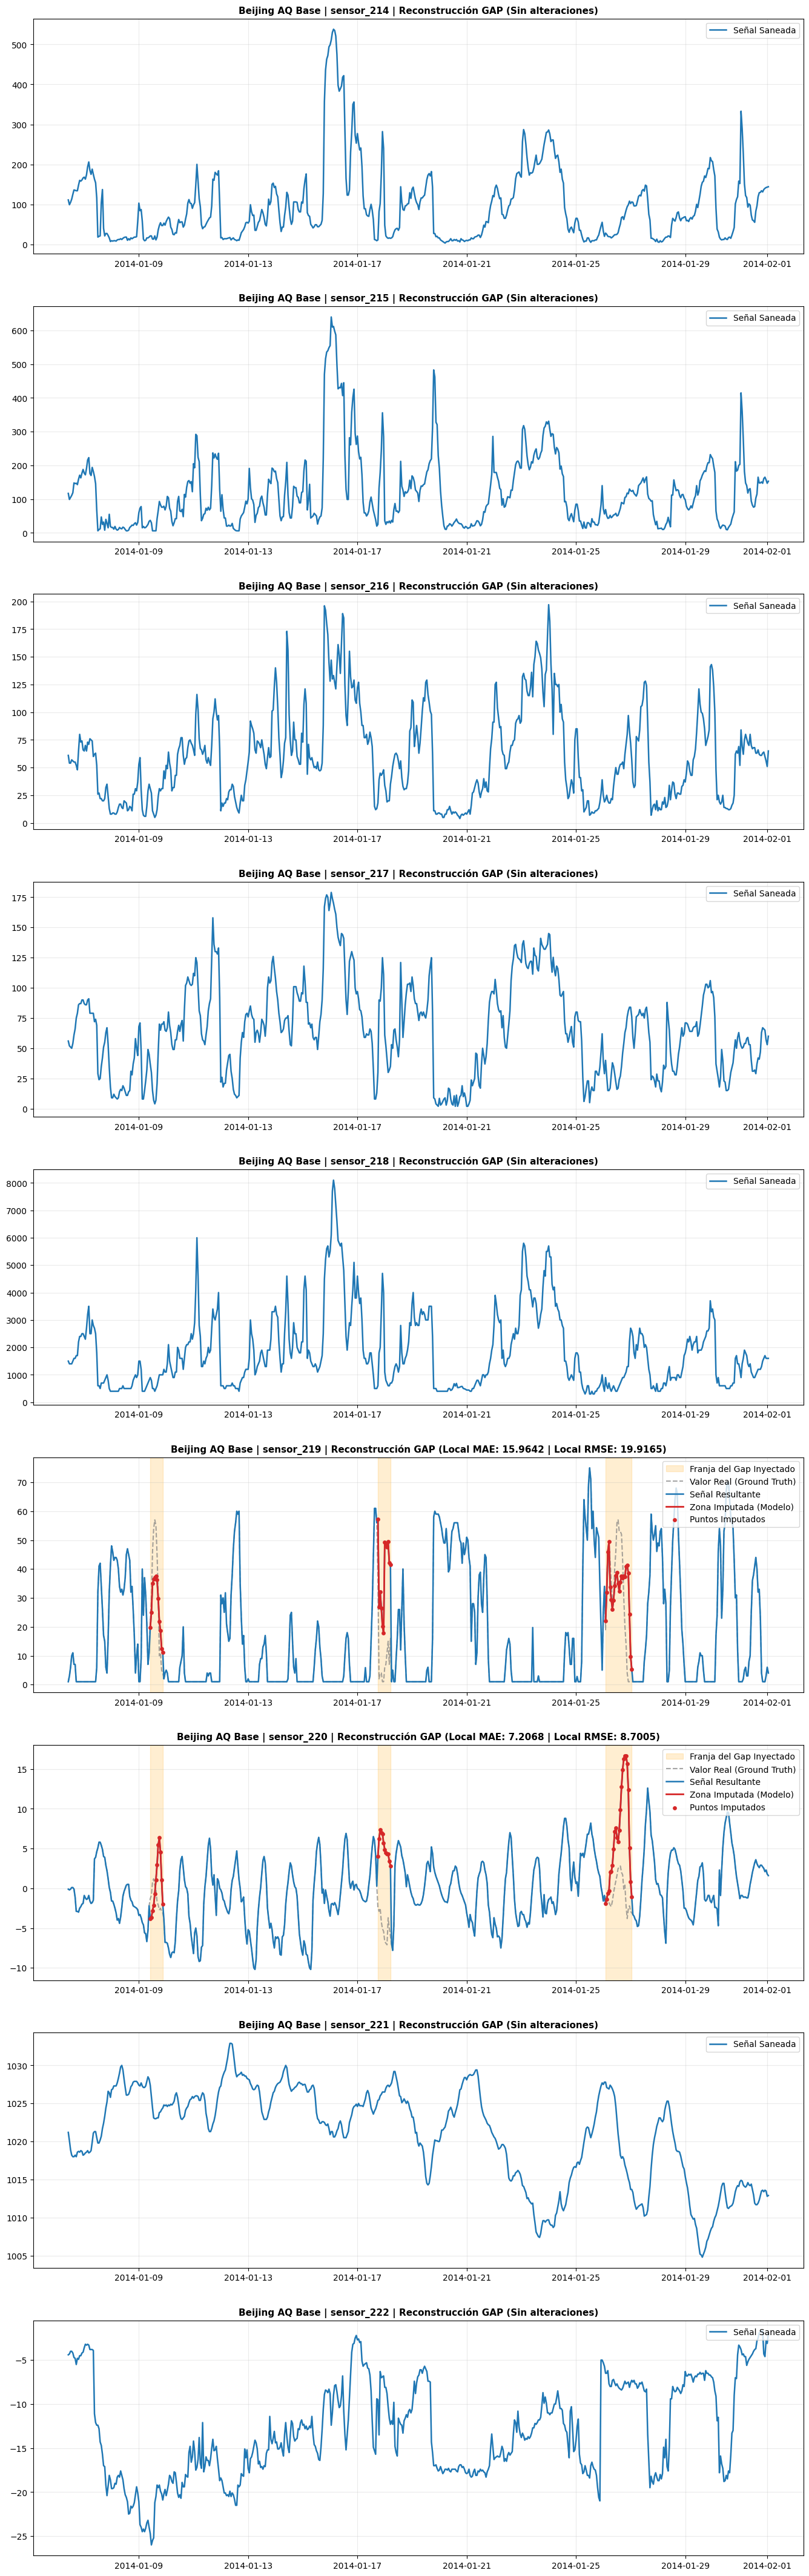

In [ ]:
graficar_diagnostico_zoom(job_uuids["Beijing_AQ"], "Beijing AQ Base", dias_zoom=3)

### 5.2. Torneo HPO y Feature Engineering

<div style="text-align: justify;">

Se exponen a continuación los rankings de los modelos evaluados en el torneo completo, ya con HPO y Feature Engineering, así como las gráficas construidas para su visualización, para cada uno de los dos datasets de evaluación.

</div>

#### 5.2.1 Alumbrado Público (Univariante)

,Rank,Modelo,MAE Gap,RMSE Gap,Fase
0,1,UNI_LIGHTGBM_TABULAR,0.0142,0.0214,HPO Optimizado
1,2,ZSCORE_LINEAR,0.7440,1.1190,HPO Optimizado


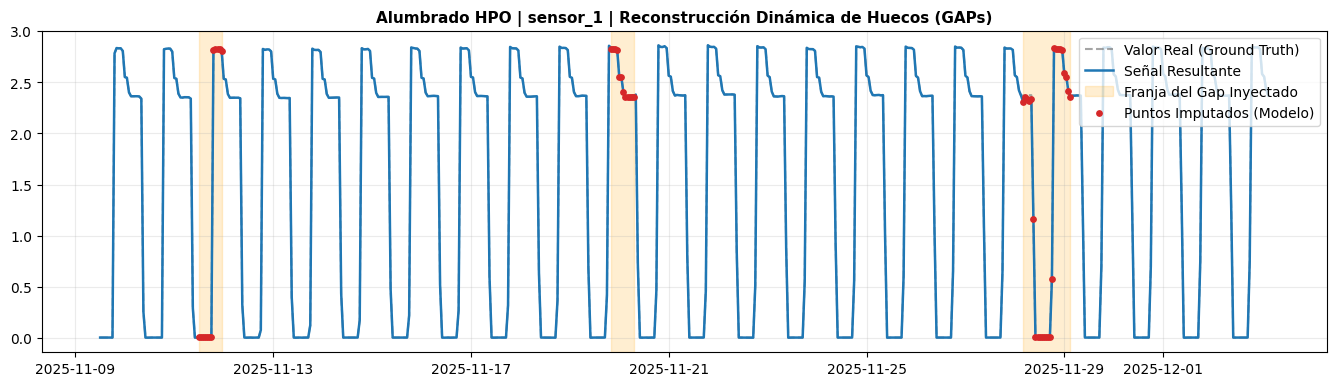

In [79]:
display(extraer_ranking_completo(hpo_job_uuids["Alumbrado"], "Alumbrado", "HPO Optimizado"))
graficar_diagnostico_zoom(hpo_job_uuids["Alumbrado"], "Alumbrado HPO", dias_zoom=2)

#### 5.2.2. Beijing Air Quality (Multivariante)

,Sensor,Intervalo GAP,Índice Inicio,Índice Fin,MAE Local,RMSE Local
0,sensor_219,GAP 1,100,112,7.6758,9.5226
1,sensor_219,GAP 2,300,312,14.4789,17.1689
2,sensor_219,GAP 3,500,524,14.0217,16.7826
3,sensor_220,GAP 1,100,112,4.6618,5.6521
4,sensor_220,GAP 2,300,312,7.7118,8.1639
5,sensor_220,GAP 3,500,524,8.9249,10.0333


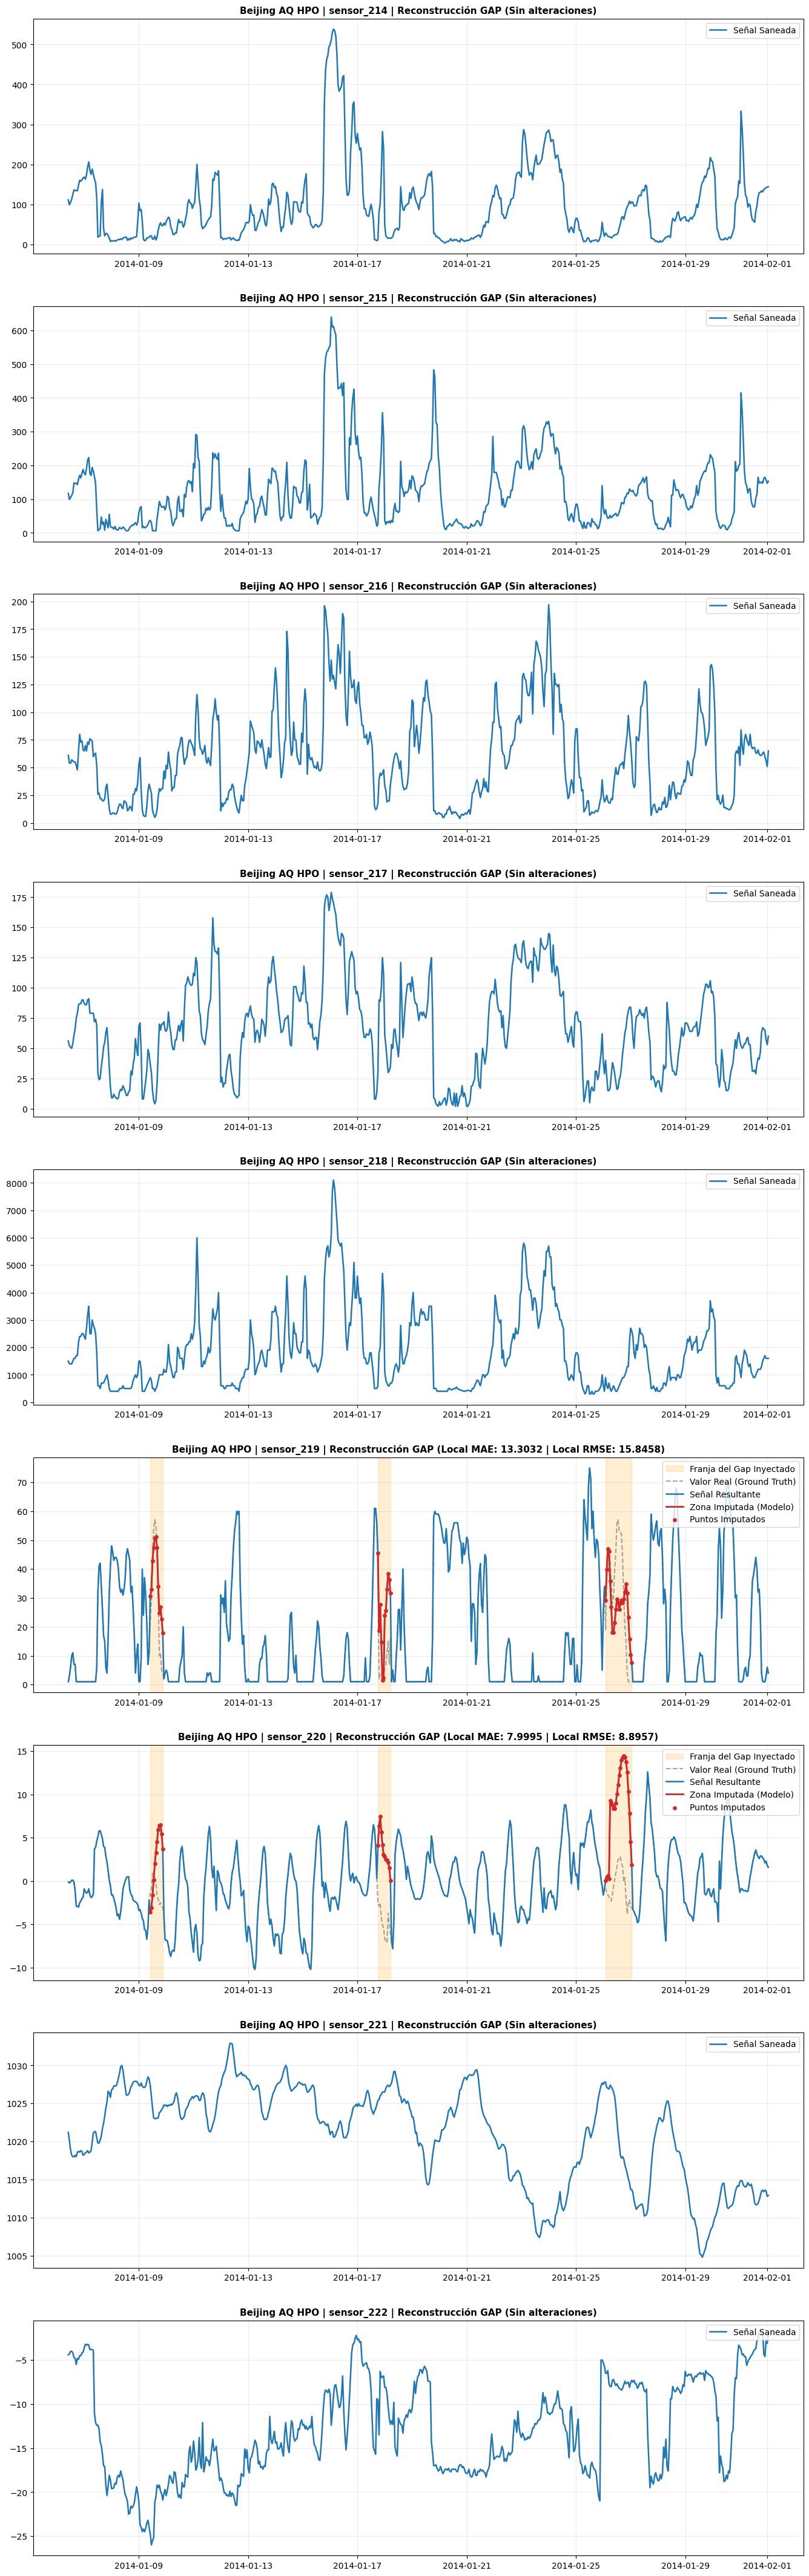

In [ ]:
display(extraer_error_desglosado_por_gap(hpo_job_uuids["Beijing_AQ"]))
graficar_diagnostico_zoom(hpo_job_uuids["Beijing_AQ"], "Beijing AQ HPO", dias_zoom=3)

## 6. Conclusiones <a id="conclusiones"></a>

<div style="text-align: justify;">

En la siguiente sección se exponen las conclusiones de los resultados obtenidos en las pruebas realizadas sobre los dos conjuntos de datos. El flujo de ejecución en el entorno Sandbox es: inyección de daños en un copia del dataset original; evaluación de los daños mediante los candidatos seleccionados (con o sin HPO); proclamción de un ganador de acuerdo con la métrica elegida. En este caso, para la tarea de imputación de huecos, se ha empleado el Error Absoluto Medio (MAE) como la métrica decisiva. A diferencia de métricas como el Error Cuadrático Medio (MSE), que presentan una limitación importante, ya que penalizan de forma desproporcionada los errores grandes o los picos aislados debido al término cuadrático, pudiendo descartar un modelo que comprende bien la tendencia general por un fallo aislado si este es significativo.

### 6.1. Alumbrado Público (Regular)

Para el dataset de alumbrado hemos comparado dos modelos diferentes: interpolación lineal, y el método basado en Gradient Boosting LightGBM.

En el torneo base, lo primero que destaca es que los errores obtenidos son los mismos para ambas simulaciones. Esto se debe a un mecansimo de protección implementado en nuestro LightGBM:

```Python
if model is None or not features:
    logger.warning("[Warning] LightGBM model unavailable for %s. Falling back to Linear.", col)
    df_result[col]=df_result[col].interpolate(method='linear', limit_direction='both')
    continue
```

Como se ve, en caso de que falle la implementación base de LightGBM, ya sea por problema en el propio modelo, o por ausencia de features (como es el caso actual), el sistema delega la imputación a una interpolación lineal que actúa de fallback en esos escenarios, y por ello en el torneo base se observan los mismos valores en ambos escenarios.

Ya en el torneo con HPO, la optimización de hiperparámetros, y principalmente, el enriqeucimiento con variables exógenas mediante el feature engineering (donde, como ocurre en al detección de anomalías, se seleccionan los lags de 24 y 48 horas, al igual que en el caso de la detección de anomalías), permite al LightGBM reconstruir los huecos de esta señal con una periodicidad tan marcada con una enorme precisión.

### 6.2. Beijing Air Quality

El análisis de las métricas de error desglosadas entre torneo base y HPO revela el impacto de la optimización de hiperparámetros en arquitecturas como \textit{SAITS}. Al comparar las Tablas~\ref{tab:errores_desglosados_beijing} y \ref{tab:errores_desglosados_beijing_hpo}, se observa que la optimización no consigue una minimización absoluta del error en todos los gaps simultáneamente, sino que actúa estabilizándolo frente a eventos extremos.

En la fase inicial, el modelo sufría un colapso evidente en el segundo hueco inyectado (GAP 2). Esta zona ocultaba un pico muy pronunciado en la señal original, y sin una optimización, se disparaba el MAE local del sensor 219 hasta 26.7689. Tras la ejecución del motor de optimización, el modelo logra reducir esta desviación hasta llegar a un error de 14.4789. Este mismo patrón de estabilización se replica en el sensor 220 durante el mismo GAP crítico, donde el MAE desciende de 9.1790 a 7.7118. Visualmente, el modelo optimizado, en lugar de trazar una línea suavizada que ignore el evento anómalo, aprende a ponderar con mayor agresividad la correlación entre las variables, intentando simular la morfología del pico oculto. 

Como contrapartida lógica a esta mayor sensibilidad a cambios abruptos, se observa un ligero aumento del error en las franjas más estables (GAP 1 y GAP 3). Por ejemplo, el MAE del sensor 220 en el GAP 3 asciende de 7.1450 a 8.9249. Al parecer, al adaptar la arquitectura para que sea más reactiva y capaz de reconstruir picos abruptos basándose en variables exógenas, el modelo se vuelve marginalmente menos preciso en las zonas planas.

Todas estas conclusiones, han de estar complementadas por las ya explciadas limitaciones de infrasestructura en que se han desarrollado, que ha limitado el tamaño del conjunto de datos empleado en las pruebas. Esta limitación en el volumen también ha de valorarse, y suponemos que dada la posibilidad de operar sobre un conjunto mayor de datos al realizar estas pruebas, las métricas de las evaluaciones realizadas en esta sección y en la anterior en relación con modelos complejos, verían sus magnitudes mejoradas casi con total seguridad.

</div>